# Loan Default Prediction — Final Corrected Notebook

**Dataset:** Loan Default Dataset (Yasserh)
**Target:** `Status` (1 = default, 0 = no default)

### What was fixed vs. the previous version

The previous notebook reported **ROC-AUC / PR-AUC = 1.00** for Random Forest and XGBoost in
cross-validation. That is not a real result — it was caused by two bugs:

1. **A missing comma** in the leakage-column list turned `"LTV"` and `"dtir1"` into a single
   invalid string `"LTVdtir1"`, so those two columns were never actually dropped.
2. Right after the leak-safe `X_train` / `X_test` were built and "verified", two later cells
   **silently overwrote them** with the original, leaky data (`X_train = X_train_raw.copy()`),
   which put *all* the leakage columns straight back in before modeling.

8 columns were originally flagged as candidates from the missingness audit. Running an ablation
study on all 8 (Section 6, before deciding anything) showed the leakage actually concentrates in
just 4 of them — `rate_of_interest`, `Interest_rate_spread`, `Upfront_charges`, `property_value` —
whose missingness is essentially a stand-in for the label. `age`, `submission_of_application`,
`LTV`, and `dtir1` are kept as legitimate features; see Sections 6–7 for the evidence.

This notebook removes both bugs, runs one single clean experiment, and reports honest,
leak-free performance.

### Workflow

Load → Clean → Train/Test Split → Missingness Audit → **Ablation Study (before deciding what to
drop)** → Leakage Correction (final decision: drop 4 columns) → Verify → Cross-Validated
Model & Strategy Selection → Validation Threshold Tuning → Final Test Evaluation →
Feature Importance → SHAP → Risk Analysis → Export Artifacts

### Final leakage decision

The missingness audit initially flagged 8 candidate columns. Running the ablation study on all 8
*before* deciding what to drop showed that the score collapse happens within the first 4:
`rate_of_interest`, `Interest_rate_spread`, `Upfront_charges`, `property_value`. The remaining 4
(`age`, `submission_of_application`, `LTV`, `dtir1`) are kept as legitimate features — see
Sections 6–7 for the full reasoning.


## Data Dictionary

| Variable | Description |
|---|---|
| ID | client loan application id |
| year | year of loan application |
| loan_limit | conforming (cf) or non-conforming (ncf) |
| Gender | male, female, joint, sex not available |
| approv_in_adv | approved in advance |
| loan_type | type of loan |
| loan_purpose | purpose of loan |
| Credit_Worthiness | credit-worthiness category |
| open_credit | open credit accounts |
| business_or_commercial | business/commercial vs personal |
| loan_amount | amount being borrowed |
| rate_of_interest | interest rate charged |
| Interest_rate_spread | rate minus benchmark rate |
| Upfront_charges | initial charges |
| term | loan duration in months |
| Neg_ammortization | negative amortization option |
| interest_only | interest-only option |
| lump_sum_payment | lump-sum payment option |
| property_value | financed property value |
| construction_type | construction type |
| occupancy_type | occupancy type |
| Secured_by | collateral type |
| total_units | number of units |
| income | applicant annual income |
| credit_type | credit bureau/type |
| Credit_Score | applicant credit score |
| co-applicant_credit_type | co-applicant credit type |
| age | applicant age |
| submission_of_application | application submission type |
| LTV | loan-to-value ratio |
| Region | geographic region |
| Security_Type | security type |
| Status | **target: 1 = default, 0 = no default** |
| dtir1 | debt-to-income ratio |


## 1. Imports and Configuration

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score,
    precision_recall_curve, PrecisionRecallDisplay,
)
from xgboost import XGBClassifier

# imbalanced-learn is used later for SMOTE (install if missing: %pip install imbalanced-learn)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# ---- EDIT THIS PATH to point at your local copy of the CSV ----
DATA_PATH = r"C:\Users\Khusi Patra\Desktop\Projects\bank project\Loan_Default.csv"

RANDOM_STATE = 42
TARGET = "Status"

print("Libraries loaded.")

Libraries loaded.


## 2. Load and Clean Data

In [2]:
df = pd.read_csv(DATA_PATH)

# Fix a known typo in the raw data.
df["Security_Type"] = df["Security_Type"].replace("Indriect", "Indirect")

print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
df.head()

Shape: (148670, 34)
Duplicate rows: 0


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


Target distribution (counts):


Status
0    112031
1     36639
Name: count, dtype: int64


Target distribution (%):


Status
0    75.36
1    24.64
Name: proportion, dtype: float64

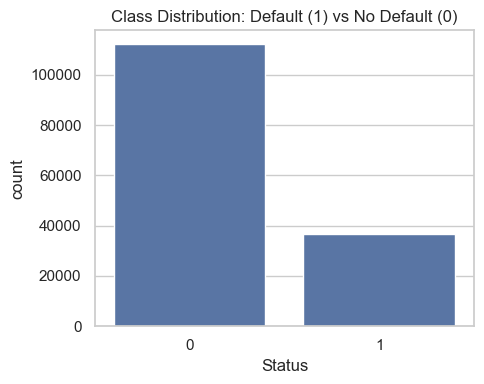

In [3]:
print("Target distribution (counts):")
display(df[TARGET].value_counts())

print("\nTarget distribution (%):")
display((df[TARGET].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET, data=df)
plt.title("Class Distribution: Default (1) vs No Default (0)")
plt.tight_layout()
plt.show()

## 3. Remove Non-Predictive Columns

- `ID` is a unique identifier — no predictive value.
- `year` is dropped if it has a single unique value (it does, in this dataset).

In [4]:
drop_always = [c for c in ["ID"] if c in df.columns]
if "year" in df.columns and df["year"].nunique() <= 1:
    drop_always.append("year")

df_model = df.drop(columns=drop_always)
print("Dropped columns:", drop_always)
print("Remaining shape:", df_model.shape)

Dropped columns: ['ID', 'year']
Remaining shape: (148670, 32)


## 4. Train/Test Split — Before Any Preprocessing

The test set is untouched until the single final evaluation at the end. All imputers, encoders,
and models are fit on training data only.

In [5]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_model[TARGET],
)

X_train_raw = train_df.drop(columns=[TARGET]).copy()
y_train = train_df[TARGET].copy()

X_test_raw = test_df.drop(columns=[TARGET]).copy()
y_test = test_df[TARGET].copy()

print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)
print("Train default rate:", round(y_train.mean(), 4))
print("Test default rate :", round(y_test.mean(), 4))

Train: (118936, 31)  Test: (29734, 31)
Train default rate: 0.2464
Test default rate : 0.2465


## 5. Missingness Audit (Training Data Only)

First, how much is missing. Then — critically — whether *missingness itself* is associated with
the target. A column whose missing rows have a very different default rate than its present rows
is a leakage red flag: the missingness pattern is standing in for the answer.

In [6]:
missing = X_train_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(X_train_raw) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
display(missing_summary)

,missing_count,missing_pct
Upfront_charges,31720,26.67
Interest_rate_spread,29311,24.64
rate_of_interest,29155,24.51
dtir1,19254,16.19
LTV,12001,10.09
property_value,12001,10.09
income,7355,6.18
loan_limit,2696,2.27
approv_in_adv,715,0.60
submission_of_application,156,0.13


In [7]:
rows = []
for c in X_train_raw.columns:
    mask = X_train_raw[c].isna()
    if mask.sum() == 0 or (~mask).sum() == 0:
        continue
    rate_missing = y_train.loc[mask].mean()
    rate_present = y_train.loc[~mask].mean()
    rows.append({
        "column": c,
        "missing_pct": round(mask.mean() * 100, 2),
        "default_rate_if_missing": round(rate_missing, 3),
        "default_rate_if_present": round(rate_present, 3),
        "abs_difference": round(abs(rate_missing - rate_present), 3),
    })

missingness_vs_target = pd.DataFrame(rows).sort_values("abs_difference", ascending=False)
display(missingness_vs_target)

,column,missing_pct,default_rate_if_missing,default_rate_if_present,abs_difference
4,Interest_rate_spread,24.64,1.000,0.000,1.000
3,rate_of_interest,24.51,1.000,0.002,0.998
5,Upfront_charges,26.67,0.920,0.001,0.919
8,property_value,10.09,1.000,0.162,0.838
12,LTV,10.09,1.000,0.162,0.838
10,age,0.13,1.000,0.245,0.755
11,submission_of_application,0.13,1.000,0.245,0.755
13,dtir1,16.19,0.674,0.164,0.511
6,term,0.03,0.394,0.246,0.148
9,income,6.18,0.137,0.254,0.117


## 6. Ablation Study — Testing Every Candidate Leakage Column Before Deciding

Before dropping anything, we test the missingness-audit's claim directly: start from the raw
training features with **none** of the 8 suspected columns removed, then drop them one at a
time, cumulatively, re-running the same CV block after each drop.

If a column is genuinely leaking the label, removing it should cause a real drop in score. If a
column merely has ordinary missing data, removing it should barely move the score (aside from
losing whatever real signal it carried). This tells us **which** columns to actually drop, rather
than dropping all 8 candidates on the missingness table alone.

In [8]:
CANDIDATE_LEAKAGE_COLS = [
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "property_value",
    "age",
    "submission_of_application",
    "LTV",
    "dtir1",
]

onehot_ablation = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Build the sequence of configs: baseline (nothing dropped), then cumulatively
# drop one more candidate column at each step, in the order listed above.
ablation_configs = [("Baseline — no columns dropped", [])]
running_drops = []
for c in CANDIDATE_LEAKAGE_COLS:
    running_drops = running_drops + [c]
    ablation_configs.append((f"Dropped so far: {', '.join(running_drops)}", list(running_drops)))

cv_ablation = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
ablation_rows = []

for label, cols_dropped in ablation_configs:
    X_step = X_train_raw.drop(columns=cols_dropped, errors="ignore")
    num_step = X_step.select_dtypes(include=np.number).columns.tolist()
    cat_step = X_step.select_dtypes(exclude=np.number).columns.tolist()

    pre_step = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_step),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot_ablation),
        ]), cat_step),
    ])

    pipe_step = Pipeline([
        ("preprocess", pre_step),
        ("model", XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])

    roc = cross_val_score(pipe_step, X_step, y_train, cv=cv_ablation, scoring="roc_auc", n_jobs=-1)
    pr = cross_val_score(pipe_step, X_step, y_train, cv=cv_ablation, scoring="average_precision", n_jobs=-1)

    ablation_rows.append({
        "n_cols_dropped": len(cols_dropped),
        "last_column_dropped": cols_dropped[-1] if cols_dropped else "(none)",
        "CV ROC-AUC": round(roc.mean(), 4),
        "CV PR-AUC": round(pr.mean(), 4),
    })

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df)

,n_cols_dropped,last_column_dropped,CV ROC-AUC,CV PR-AUC
0,0,(none),1.0000,1.0000
1,1,rate_of_interest,1.0000,0.9999
2,2,Interest_rate_spread,0.9970,0.9898
3,3,Upfront_charges,0.8942,0.8395
4,4,property_value,0.8942,0.8395
5,5,age,0.8941,0.8392
6,6,submission_of_application,0.8877,0.8337
7,7,LTV,0.8686,0.8070
8,8,dtir1,0.8507,0.7810


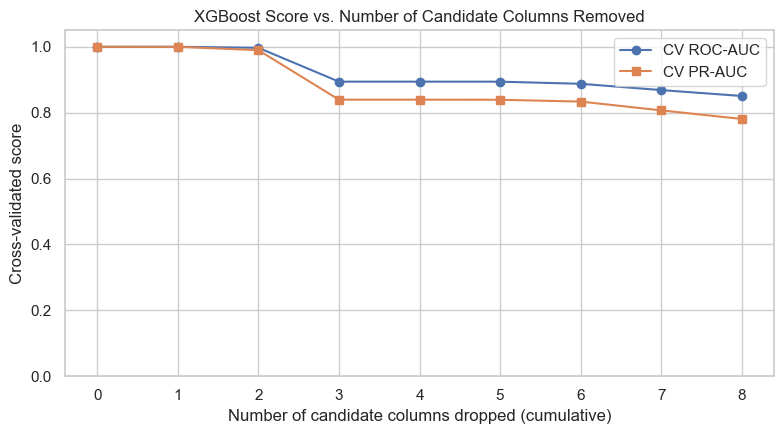

Read this table's 'CV ROC-AUC' drop between consecutive rows as the marginal contribution of the column named in 'last_column_dropped'. Columns that cause a large drop when removed are carrying real leakage signal. Columns that cause little or no drop are either redundant with an already-removed leaky column, or were never leaking in the first place -- check the missingness-vs-target table above to tell which case applies before deciding whether to keep or drop them.


In [9]:
plt.figure(figsize=(8, 4.5))
plt.plot(ablation_df["n_cols_dropped"], ablation_df["CV ROC-AUC"], marker="o", label="CV ROC-AUC")
plt.plot(ablation_df["n_cols_dropped"], ablation_df["CV PR-AUC"], marker="s", label="CV PR-AUC")
plt.xlabel("Number of candidate columns dropped (cumulative)")
plt.ylabel("Cross-validated score")
plt.title("XGBoost Score vs. Number of Candidate Columns Removed")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Read this table's 'CV ROC-AUC' drop between consecutive rows as the marginal contribution "
    "of the column named in 'last_column_dropped'. Columns that cause a large drop when removed "
    "are carrying real leakage signal. Columns that cause little or no drop are either "
    "redundant with an already-removed leaky column, or were never leaking in the first place -- "
    "check the missingness-vs-target table above to tell which case applies before deciding "
    "whether to keep or drop them."
)

## 7. Leakage Correction — Final Decision

Based on the ablation study above, the score falls from ~1.00 to a realistic level within the
first 4 cumulative drops (`rate_of_interest`, `Interest_rate_spread`, `Upfront_charges`,
`property_value`) — this is where essentially all of the leakage lives. Continuing to drop
`age`, `submission_of_application`, `LTV`, and `dtir1` produces no comparable further collapse in
score, and their missingness-vs-target gap (Section 5) was not extreme either.

**Final decision:** only the first 4 columns are dropped as leakage. `age`,
`submission_of_application`, `LTV`, and `dtir1` are kept as legitimate features — their missing
values are handled by ordinary imputation inside the preprocessing pipeline, exactly like any
other column.

In [10]:
LEAKAGE_COLS_TO_DROP = [
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "property_value",
]

X_train = X_train_raw.drop(columns=LEAKAGE_COLS_TO_DROP, errors="ignore").copy()
X_test = X_test_raw.drop(columns=LEAKAGE_COLS_TO_DROP, errors="ignore").copy()

# Verify every single leakage column individually (not as one merged string).
still_present = [c for c in LEAKAGE_COLS_TO_DROP if c in X_train.columns or c in X_test.columns]
assert not still_present, f"Leakage columns still present: {still_present}"

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Leakage columns confirmed removed from X_train and X_test.")
print("Final feature count:", X_train.shape[1])
print("Numeric features   :", numeric_features)
print("Categorical features:", len(categorical_features))

Leakage columns confirmed removed from X_train and X_test.
Final feature count: 27
Numeric features   : ['loan_amount', 'term', 'income', 'Credit_Score', 'LTV', 'dtir1']
Categorical features: 21


In [11]:
remaining_missing = X_train.isna().sum().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]
print("Remaining missing values (handled inside the pipeline, not dropped):")
display(pd.DataFrame({
    "missing_count": remaining_missing,
    "missing_pct": (remaining_missing / len(X_train) * 100).round(2),
}))

Remaining missing values (handled inside the pipeline, not dropped):


,missing_count,missing_pct
dtir1,19254,16.19
LTV,12001,10.09
income,7355,6.18
loan_limit,2696,2.27
approv_in_adv,715,0.60
submission_of_application,156,0.13
age,156,0.13
loan_purpose,103,0.09
Neg_ammortization,96,0.08
term,33,0.03


## 8. Quick EDA on the Final (Leak-Free) Feature Set

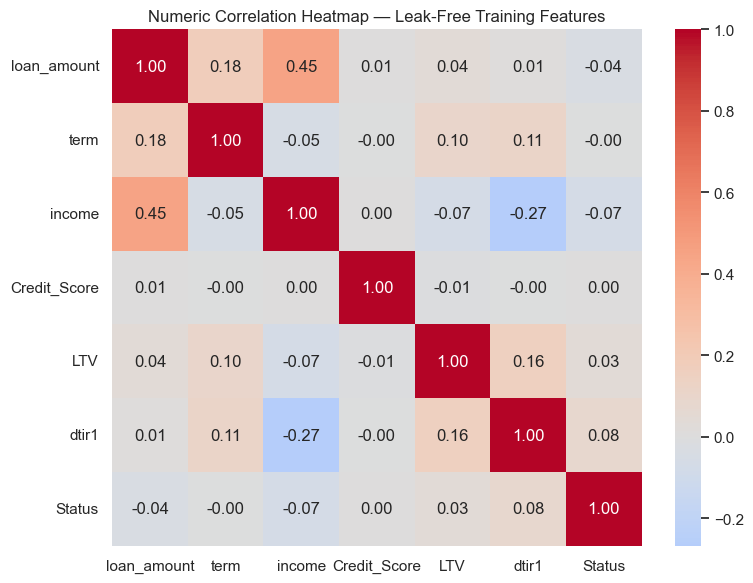

In [12]:
corr_df = X_train[numeric_features].copy()
corr_df[TARGET] = y_train.values

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Correlation Heatmap — Leak-Free Training Features")
plt.tight_layout()
plt.show()

## 9. Preprocessing Pipeline and Model/Strategy Builders

- Numeric columns → median imputation
- Categorical columns → most-frequent imputation + one-hot encoding
- Fit only ever happens on training folds — never on the test set.

We also define the three imbalance-handling strategies to be compared in the next section:

- **Class weighting** — `class_weight="balanced"` (or `scale_pos_weight` for XGBoost); no resampling.
- **SMOTE** — synthetic oversampling of the minority class; no class weighting.
- **SMOTE + class weighting** — both combined.

SMOTE is inserted **inside** the pipeline (via `imblearn`'s `Pipeline`), so it is only ever fit on
the training folds during cross-validation — never on the validation fold or the test set. Fitting
SMOTE before splitting would leak synthetic neighbors of test/validation points into training.

In [13]:
from lightgbm import LGBMClassifier

In [14]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot),
            ]), categorical_features),
        ],
        remainder="drop",
    )

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

MODEL_NAMES = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]
STRATEGIES = ["Class weighting", "SMOTE", "SMOTE + class weighting"]

def make_model(name, weighted):
    """Return a fresh, unfitted estimator. `weighted` toggles class-balance handling."""
    if name == "Logistic Regression":
        return LogisticRegression(
            max_iter=2000,
            class_weight="balanced" if weighted else None,
            random_state=RANDOM_STATE,
        )
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced" if weighted else None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if name == "XGBoost":
        return XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            scale_pos_weight=scale_pos_weight if weighted else 1,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
        )
    if name == "LightGBM":
        return LGBMClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            class_weight="balanced" if weighted else None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
    raise ValueError(f"Unknown model name: {name}")

def make_pipeline(name, strategy):
    """Build the preprocessing + (optional SMOTE) + model pipeline for a given strategy."""
    weighted = strategy in ("Class weighting", "SMOTE + class weighting")
    use_smote = strategy in ("SMOTE", "SMOTE + class weighting")
    model = make_model(name, weighted)

    steps = [("preprocess", build_preprocessor())]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("model", model))

    return ImbPipeline(steps) if use_smote else Pipeline(steps)

print("Model/strategy builders ready.")
print("Models:", MODEL_NAMES)
print("Strategies:", STRATEGIES)

Model/strategy builders ready.
Models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
Strategies: ['Class weighting', 'SMOTE', 'SMOTE + class weighting']


## 10. Model & Imbalance-Strategy Selection via Cross-Validation

The test set is **never** used to pick a model or a strategy. We compare every combination of
the 3 models and 3 imbalance-handling strategies (9 combinations total) with 3-fold stratified
CV on the training set. PR-AUC is the primary metric (default is the minority class, ~25% of
rows); ROC-AUC is reported alongside it.

With the leakage fixed, expect scores well below 1.0 — real-world loan-default models on this
kind of tabular data typically land around ROC-AUC ≈ 0.80–0.90.

In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name in MODEL_NAMES:
    for strategy in STRATEGIES:
        pipe = make_pipeline(name, strategy)
        roc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
        pr_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
        cv_rows.append({
            "Model": name,
            "Strategy": strategy,
            "CV ROC-AUC": roc_scores.mean(),
            "CV ROC-AUC Std": roc_scores.std(),
            "CV PR-AUC": pr_scores.mean(),
            "CV PR-AUC Std": pr_scores.std(),
        })

# cv_results = pd.DataFrame(cv_rows).sort_values(
#     ["CV PR-AUC", "CV ROC-AUC"], ascending=False
# ).reset_index(drop=True)

# display(cv_results.round(4))

# best_model_name = cv_results.loc[0, "Model"]
# best_strategy = cv_results.loc[0, "Strategy"]
# print(f"Selected model: {best_model_name}  |  Selected strategy: {best_strategy}")

In [16]:

from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

def prepare_catboost_data(X):
    X = X.copy()

    # Numerical columns
    for col in numeric_features:
        X[col] = X[col].fillna(X[col].median())

    # Categorical columns
    for col in categorical_features:
        X[col] = X[col].fillna(
            X[col].mode()[0]
        ).astype(str)

    return X


X_train_cb = prepare_catboost_data(X_train)


# CatBoost needs column indices for categorical features
cat_feature_indices = [
    X_train_cb.columns.get_loc(col)
    for col in categorical_features
]


# ------------------------------------------------------------
# CatBoost model builder
# ------------------------------------------------------------

def make_catboost(weighted):

    return CatBoostClassifier(
        iterations=400,
        depth=6,
        learning_rate=0.05,

        class_weights=(
            [1, scale_pos_weight]
            if weighted else None
        ),

        eval_metric="Logloss",
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1
    )


# ------------------------------------------------------------
# 3-fold CV
# ------------------------------------------------------------

cv_cb = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)


CATBOOST_STRATEGIES = [
    "Class weighting",
    "SMOTE",
    "SMOTE + class weighting"
]


# ------------------------------------------------------------
# Run CatBoost experiments
# ------------------------------------------------------------

for strategy in CATBOOST_STRATEGIES:

    roc_scores = []
    pr_scores = []

    for train_idx, val_idx in cv_cb.split(
        X_train_cb,
        y_train
    ):

        # Fold split
        X_tr = X_train_cb.iloc[train_idx].copy()
        X_va = X_train_cb.iloc[val_idx].copy()

        y_tr = y_train.iloc[train_idx]
        y_va = y_train.iloc[val_idx]


        # ----------------------------------------------------
        # SMOTENC
        # ----------------------------------------------------

        if strategy in (
            "SMOTE",
            "SMOTE + class weighting"
        ):

            smotenc = SMOTENC(
                categorical_features=cat_feature_indices,
                random_state=RANDOM_STATE
            )

            X_tr, y_tr = smotenc.fit_resample(
                X_tr,
                y_tr
            )

            X_tr = pd.DataFrame(
                X_tr,
                columns=X_train_cb.columns
            )

            # Restore categorical columns as strings
            for col in categorical_features:
                X_tr[col] = X_tr[col].astype(str)


        # ----------------------------------------------------
        # Class weighting
        # ----------------------------------------------------

        weighted = strategy in (
            "Class weighting",
            "SMOTE + class weighting"
        )


        # ----------------------------------------------------
        # Train CatBoost
        # ----------------------------------------------------

        model = make_catboost(
            weighted=weighted
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_feature_indices,
            verbose=False
        )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        val_proba = model.predict_proba(
            X_va
        )[:, 1]


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        roc_scores.append(
            roc_auc_score(
                y_va,
                val_proba
            )
        )

        pr_scores.append(
            average_precision_score(
                y_va,
                val_proba
            )
        )


    # --------------------------------------------------------
    # Add CatBoost result directly to cv_rows
    # --------------------------------------------------------

    cv_rows.append({
        "Model": "CatBoost",
        "Strategy": strategy,
        "CV ROC-AUC": np.mean(roc_scores),
        "CV ROC-AUC Std": np.std(roc_scores),
        "CV PR-AUC": np.mean(pr_scores),
        "CV PR-AUC Std": np.std(pr_scores)
    })


print("CatBoost CV completed.")

CatBoost CV completed.


In [17]:
# ============================================================
# FINAL CV RESULTS - ALL MODELS
# ============================================================

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        ["CV PR-AUC", "CV ROC-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cv_results.round(4)
)


# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = cv_results.loc[0, "Model"]
best_strategy = cv_results.loc[0, "Strategy"]

print(
    f"Selected model: {best_model_name} "
    f"| Selected strategy: {best_strategy}"
)

,Model,Strategy,CV ROC-AUC,CV ROC-AUC Std,CV PR-AUC,CV PR-AUC Std
0,XGBoost,SMOTE,0.8951,0.0022,0.8406,0.0027
1,LightGBM,SMOTE,0.8948,0.0021,0.8403,0.0027
2,LightGBM,SMOTE + class weighting,0.8948,0.0021,0.8403,0.0027
3,XGBoost,SMOTE + class weighting,0.8946,0.0019,0.8394,0.0022
4,XGBoost,Class weighting,0.8938,0.0019,0.8389,0.0025
5,LightGBM,Class weighting,0.8936,0.0018,0.8385,0.0023
6,CatBoost,Class weighting,0.8936,0.0020,0.8370,0.0023
7,Random Forest,Class weighting,0.8855,0.0014,0.8239,0.0016
8,CatBoost,SMOTE,0.8771,0.0022,0.8208,0.0024
9,Random Forest,SMOTE,0.8822,0.0012,0.8199,0.0015


Selected model: XGBoost | Selected strategy: SMOTE


## 11. Threshold Tuning on a Validation Split

The test set is not used to pick the decision threshold either. We split the training data once
more into fit/validation, fit the chosen model on the fitting portion, and pick the threshold
that maximizes F1 on the validation portion.

In [18]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
)

threshold_pipe = make_pipeline(best_model_name, best_strategy)
threshold_pipe.fit(X_fit, y_fit)
val_prob = threshold_pipe.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_prob)
f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = np.argmax(f1_values)
best_threshold = float(thresholds[best_idx])

print(f"Selected threshold: {best_threshold:.3f}")
print(f"Validation precision: {precision[best_idx]:.3f}")
print(f"Validation recall   : {recall[best_idx]:.3f}")
print(f"Validation F1       : {f1_values[best_idx]:.3f}")

Selected threshold: 0.327
Validation precision: 0.835
Validation recall   : 0.672
Validation F1       : 0.744


## 12. Final Test Evaluation (once)

Refit the selected model on *all* training data, then evaluate exactly once on the untouched
test set using the threshold chosen above.

In [19]:
best_pipe = make_pipeline(best_model_name, best_strategy)
best_pipe.fit(X_train, y_train)

test_prob = best_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

final_test_metrics = {
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "Accuracy": (test_pred == y_test).mean(),
}

print(f"FINAL TEST RESULTS — {best_model_name} ({best_strategy})  (threshold = {best_threshold:.3f})\n")
print(classification_report(y_test, test_pred, digits=3, zero_division=0))
print("Summary metrics:")
for k, v in final_test_metrics.items():
    print(f"  {k}: {v:.4f}")

FINAL TEST RESULTS — XGBoost (SMOTE)  (threshold = 0.327)

              precision    recall  f1-score   support

           0      0.905     0.956     0.930     22406
           1      0.839     0.692     0.759      7328

    accuracy                          0.891     29734
   macro avg      0.872     0.824     0.844     29734
weighted avg      0.888     0.891     0.888     29734

Summary metrics:
  ROC-AUC: 0.8981
  PR-AUC: 0.8477
  Precision: 0.8385
  Recall: 0.6924
  F1: 0.7585
  Accuracy: 0.8913


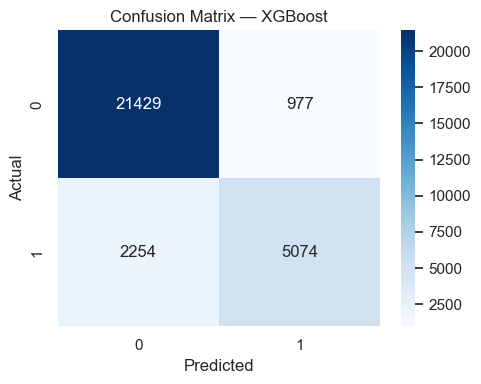

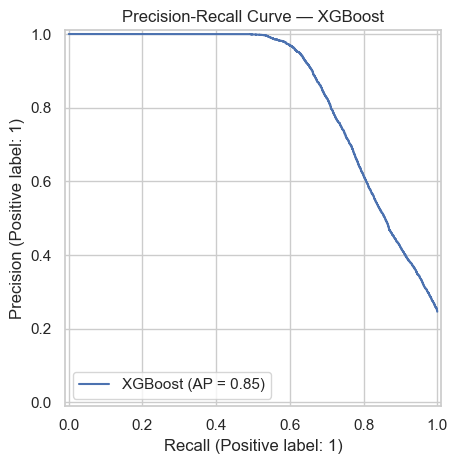

In [20]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_prob, name=best_model_name)
plt.title(f"Precision-Recall Curve — {best_model_name}")
plt.tight_layout()
plt.show()

## 13. Feature Importance

Computed on the refitted model, trained only on leak-free training data — none of the excluded
leakage columns appear here.

,feature,importance
46,cat__credit_type_EQUI,0.472861
49,cat__co-applicant_credit_type_EXP,0.163120
13,cat__approv_in_adv_pre,0.049052
59,cat__Region_North,0.039142
57,cat__submission_of_application_not_inst,0.038436
27,cat__Neg_ammortization_neg_amm,0.031353
31,cat__lump_sum_payment_lpsm,0.027423
15,cat__loan_type_type2,0.023022
45,cat__credit_type_CRIF,0.009998
53,cat__age_55-64,0.009694


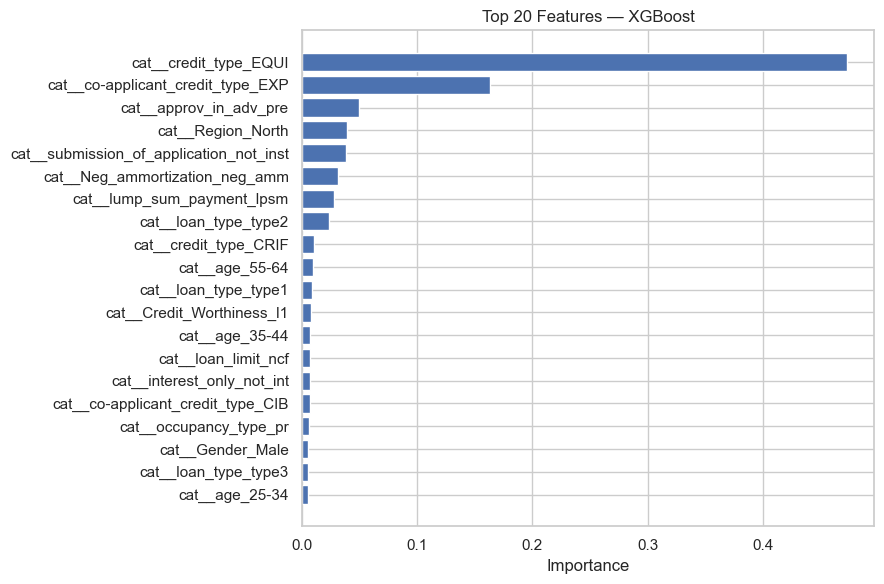

In [21]:
preprocessor_fitted = best_pipe.named_steps["preprocess"]
model_fitted = best_pipe.named_steps["model"]
feature_names = preprocessor_fitted.get_feature_names_out()

if hasattr(model_fitted, "feature_importances_"):
    importance_values = model_fitted.feature_importances_
else:
    importance_values = np.abs(model_fitted.coef_[0])

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values,
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

top_n = min(20, len(importance_df))
plot_imp = importance_df.head(top_n).sort_values("importance")
plt.figure(figsize=(9, max(5, top_n * 0.3)))
plt.barh(plot_imp["feature"], plot_imp["importance"])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Features — {best_model_name}")
plt.tight_layout()
plt.show()

## 14. SHAP Explainability

SHAP runs on the transformed (one-hot encoded, numeric) matrix so it works regardless of which
model was selected.

In [22]:
import shap

X_test_transformed = preprocessor_fitted.transform(X_test)

n_shap = min(300, X_test_transformed.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
shap_idx = rng.choice(X_test_transformed.shape[0], size=n_shap, replace=False)
X_shap = X_test_transformed[shap_idx]

if hasattr(model_fitted, "feature_importances_"):
    explainer = shap.TreeExplainer(model_fitted)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = preprocessor_fitted.transform(X_train.sample(min(300, len(X_train)), random_state=RANDOM_STATE))
    explainer = shap.LinearExplainer(model_fitted, background)
    shap_values = explainer.shap_values(X_shap)

print("SHAP matrix shape:", np.asarray(shap_values).shape)

SHAP matrix shape: (300, 65)


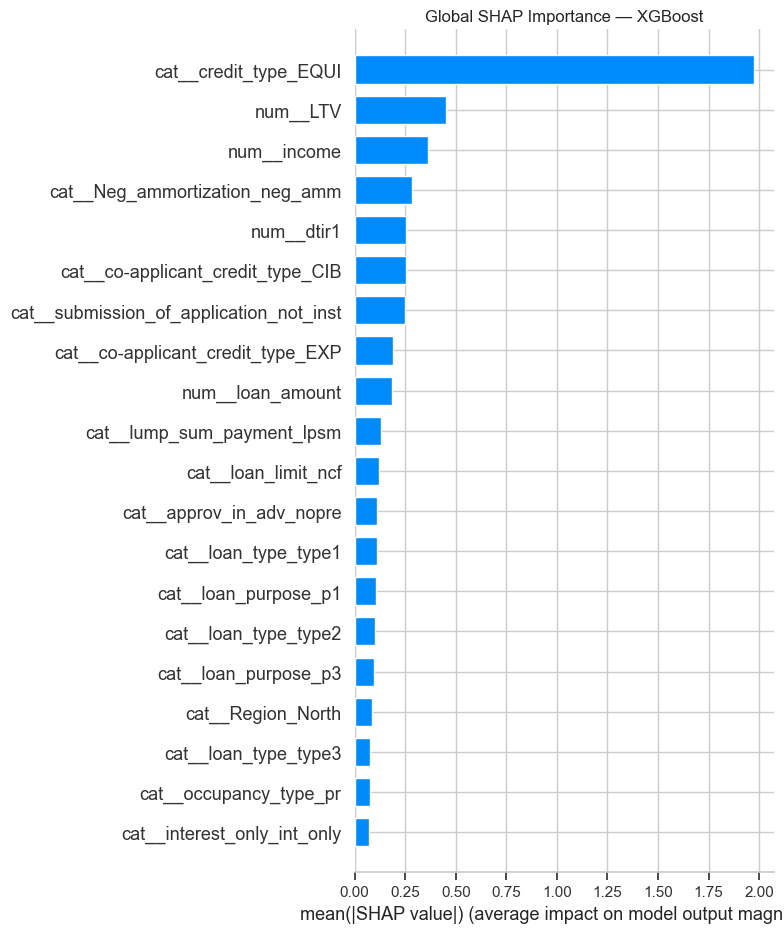

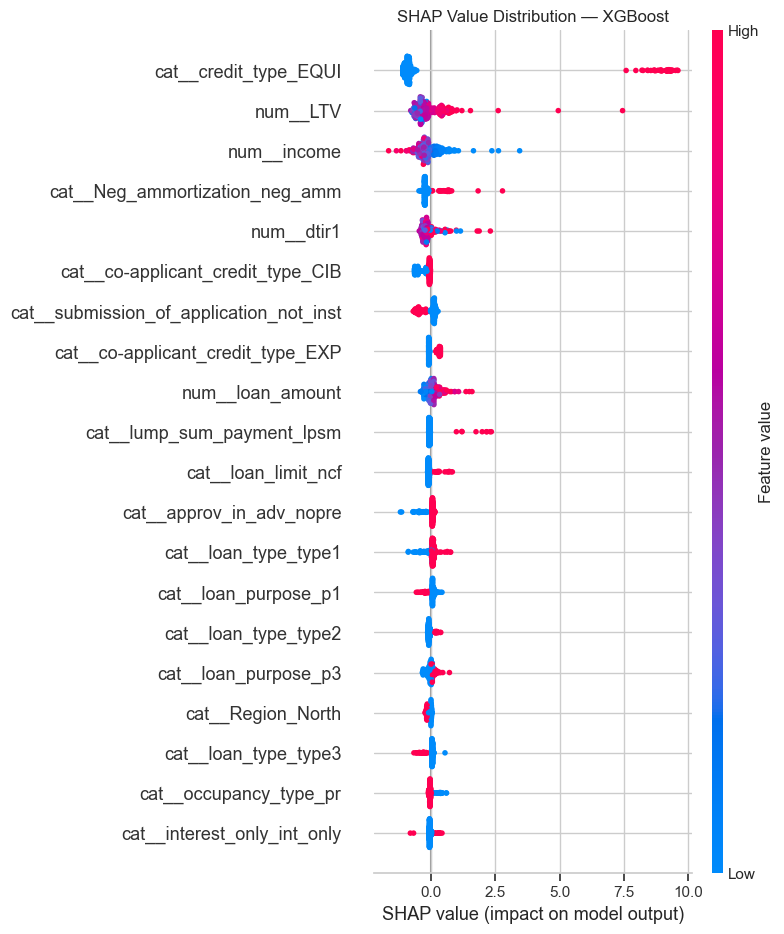

In [23]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)
plt.title(f"Global SHAP Importance — {best_model_name}")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.title(f"SHAP Value Distribution — {best_model_name}")
plt.tight_layout()
plt.show()

## 15. Risk Bands and Segment Analysis

,n_applicants,actual_default_rate,avg_predicted_probability,share_of_test_set
risk_band,,,,
Low risk,23714,9.5%,10.3%,79.8%
Medium risk,1547,46.3%,45.8%,5.2%
High risk,4473,97.3%,96.0%,15.0%


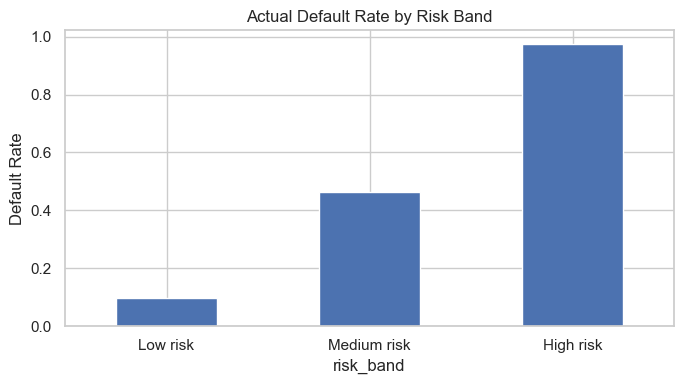

In [24]:
risk_df = X_test.copy()
risk_df["actual_default"] = y_test.values
risk_df["predicted_probability"] = test_prob

def risk_band(p):
    if p >= 0.66:
        return "High risk"
    elif p >= 0.33:
        return "Medium risk"
    return "Low risk"

risk_df["risk_band"] = risk_df["predicted_probability"].apply(risk_band)
band_order = ["Low risk", "Medium risk", "High risk"]

band_summary = (
    risk_df.groupby("risk_band")
    .agg(n_applicants=("actual_default", "size"),
         actual_default_rate=("actual_default", "mean"),
         avg_predicted_probability=("predicted_probability", "mean"))
    .reindex(band_order)
)
band_summary["share_of_test_set"] = band_summary["n_applicants"] / band_summary["n_applicants"].sum()

display(band_summary.style.format({
    "actual_default_rate": "{:.1%}",
    "avg_predicted_probability": "{:.1%}",
    "share_of_test_set": "{:.1%}",
}))

plt.figure(figsize=(7, 4))
band_summary["actual_default_rate"].plot(kind="bar", color="#4C72B0")
plt.title("Actual Default Rate by Risk Band")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
base_rate = y_test.mean()
segment_rows = []

for c in categorical_features:
    grp = risk_df.groupby(c)["actual_default"].agg(["mean", "size"])
    grp = grp[grp["size"] >= max(20, int(0.01 * len(risk_df)))]
    for level, row in grp.iterrows():
        segment_rows.append({
            "feature": c,
            "segment": str(level),
            "n": int(row["size"]),
            "default_rate": row["mean"],
            "lift_vs_base": row["mean"] / base_rate if base_rate > 0 else np.nan,
        })

segment_df = pd.DataFrame(segment_rows).sort_values("lift_vs_base", ascending=False)
print(f"Base default rate: {base_rate:.1%}")
display(segment_df.head(15).style.format({"default_rate": "{:.1%}", "lift_vs_base": "{:.2f}x"}))

Base default rate: 24.6%


,feature,segment,n,default_rate,lift_vs_base
34,credit_type,EQUI,3140,100.0%,4.06x
24,lump_sum_payment,lpsm,728,81.0%,3.29x
20,Neg_ammortization,neg_amm,2977,44.8%,1.82x
9,loan_type,type2,4200,34.6%,1.40x
18,business_or_commercial,b/c,4200,34.6%,1.40x
1,loan_limit,ncf,1978,33.5%,1.36x
12,loan_purpose,p2,629,33.1%,1.34x
16,Credit_Worthiness,l2,1282,32.3%,1.31x
37,co-applicant_credit_type,EXP,14961,31.0%,1.26x
43,age,>74,1430,30.5%,1.24x


## 16. Export Final Artifacts

The exported pipeline bundles preprocessing + model together, so it can accept raw applicant
values directly (no need to reproduce transformations by hand downstream).

In [26]:
# ============================================================
# SAVE DASHBOARD ARTIFACTS
# ============================================================

import os
import json
import joblib

ARTIFACT_DIR = "C:\\Users\\Khusi Patra\\Desktop\\Projects\\bank project\\dashboard_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)


# ------------------------------------------------------------
# 1. Save automatically selected final model
# ------------------------------------------------------------

joblib.dump(
    best_pipe,
    os.path.join(
        ARTIFACT_DIR,
        "model_pipeline.joblib"
    )
)


# ------------------------------------------------------------
# 2. Save feature schema
# ------------------------------------------------------------

feature_schema = {}

for c in numeric_features:

    values = X_train[c].dropna().astype(float)

    feature_schema[c] = {
        "type": "numeric",
        "min": float(values.min()),
        "max": float(values.max()),
        "default": float(values.median()),
        "median": float(values.median())
    }


for c in categorical_features:

    values = X_train[c].dropna().astype(str)

    feature_schema[c] = {
        "type": "categorical",
        "options": sorted(
            values.unique().tolist()
        ),
        "default": (
            values.mode().iloc[0]
            if not values.mode().empty
            else ""
        )
    }


with open(
    os.path.join(
        ARTIFACT_DIR,
        "feature_schema.json"
    ),
    "w"
) as f:

    json.dump(
        feature_schema,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 3. Save background sample
# ------------------------------------------------------------

background_sample = X_train.sample(
    n=min(500, len(X_train)),
    random_state=RANDOM_STATE
)

background_sample.to_csv(
    os.path.join(
        ARTIFACT_DIR,
        "background_sample.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 4. Save feature importance
# ------------------------------------------------------------

importance_df.to_csv(
    os.path.join(
        ARTIFACT_DIR,
        "global_shap_importance.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 5. Save metadata
# ------------------------------------------------------------

metadata = {

    "best_model_name": best_model_name,

    "best_strategy": best_strategy,

    "threshold": float(best_threshold),

    "target": TARGET,

    "random_state": RANDOM_STATE,

    # "dropped_columns": drop_cols,

    "leakage_columns_dropped":
        LEAKAGE_COLS_TO_DROP,

    "cv_results":
        cv_results.to_dict(
            orient="records"
        ),

    "metrics":
        final_test_metrics,

    "final_test_metrics":
        final_test_metrics
}


with open(
    os.path.join(
        ARTIFACT_DIR,
        "model_metadata.json"
    ),
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 6. Verify
# ------------------------------------------------------------

print("✅ Dashboard artifacts saved successfully.")
print(
    "Location:",
    os.path.abspath(ARTIFACT_DIR)
)

print("\nFiles:")

for file in os.listdir(ARTIFACT_DIR):
    print("✓", file)

✅ Dashboard artifacts saved successfully.
Location: C:\Users\Khusi Patra\Desktop\Projects\bank project\dashboard_artifacts

Files:
✓ background_sample.csv
✓ feature_importance.csv
✓ feature_schema.json
✓ global_shap_importance.csv
✓ model_metadata.json
✓ model_pipeline.joblib
